/home/konrad/.local/pipx/venvs/jupyterlab/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/konrad/.local/pipx/venvs/jupyterlab/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


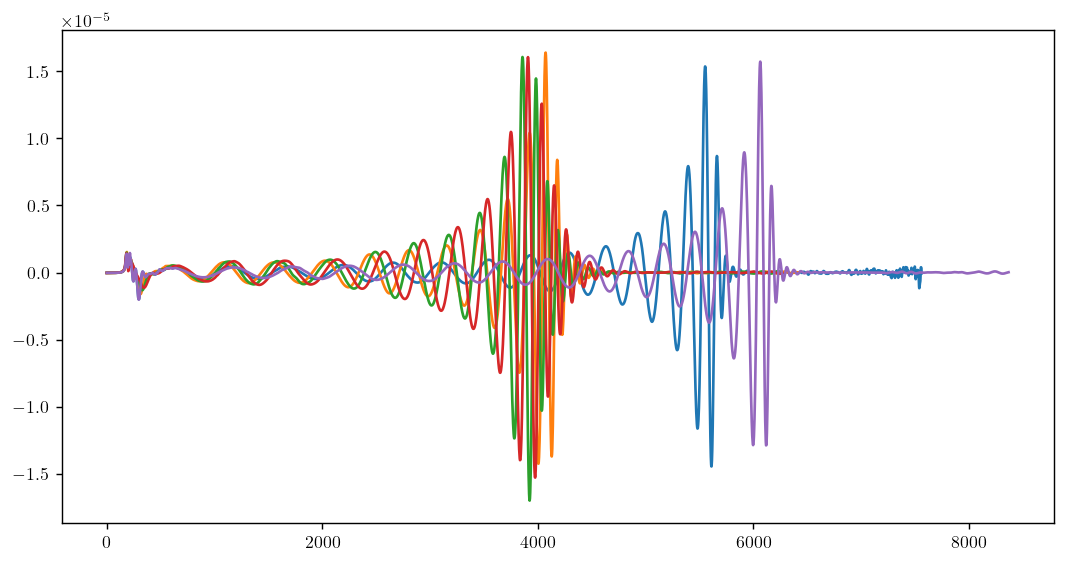

In [1]:
import os.path
import scipy as scp
import numpy as np, sys, math, itertools, argparse
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import NullFormatter
from kuibit.simdir import SimDir, load_SimDir
from kuibit.grid_data import UniformGrid, UniformGridData
from kuibit.timeseries import TimeSeries, remove_duplicated_iters
from kuibit import grid_data as gd
from kuibit import grid_data_utils as gdu
from kuibit import series
from matplotlib.colors import LogNorm
from matplotlib import ticker, cm
from matplotlib.ticker import LogFormatter, FixedLocator
import cmasher as cmr 
from numpy.ma import masked_array
from matplotlib.gridspec import GridSpec
from matplotlib.collections import PatchCollection
from kuibit.frequencyseries import FrequencySeries


plt.rcParams.update({
   # 'figure.figsize'    : [6.0, 6.0],
    'text.usetex'       : True,
    'font.family'       : "serif",
    'font.serif'        : "cm",
})

mpl.rcParams['savefig.dpi']=128             
#mpl.rcParams['figure.subplot.bottom']=.125   
mpl.rc('text.latex', preamble=r'\usepackage{amsmath}')


# nuclear saturation density in units of [1/MSUN^2]
NuclearSaturationDensity = 4.36592 * np.power(10.0,-4)
MpcToLMsol= 2.089152052322275e+19

def format_tex(float_number):
    exponent = np.floor(np.log10(float_number))
    mantissa = float_number/10**exponent
    mantissa_format = str(mantissa)[0:3]
    #return r"${0}\times10^{{{1}}}$"\
    #       .format(mantissa_format, str(int(exponent)))
    return r"$10^{{{1}}}$"           .format(mantissa_format, str(int(exponent)))

def format_tex_with_front(float_number):
    exponent = np.floor(np.log10(float_number))
    mantissa = float_number/10**exponent
    mantissa_format = str(mantissa)[0:3]
    return r"${0}\times10^{{{1}}}$"           .format(mantissa_format, str(int(exponent)))

def find_nearest_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])


"""
=========  set the directory for the simulation =========
"""

dir="./CollectData/"

rhoETtonb = 2314.995851960494 #unit.urho/unit.BaryonMassgr/(unit.invFmToInvCm**3.)


sim_to_title={
    #"BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : r"$\chi_{\rm BH}=0$",
    #"BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : r"$\chi_{\rm BH}=0.4$",
    #"BHNS_Visualisation_q0.333_chiBH0.85_Mtot6.4_Z4c_Gauge_SimilarSam" : r"$\chi_{\rm BH}=0.85$",
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : r"$\chi_{_{\rm BH}}=0.8, q^{-1}=4$",
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : r"$\chi_{_{\rm BH}}=0.8, q^{-1}=5$",
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : r"$\chi_{_{\rm BH}}=0.8, q^{-1}=6$",
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : r"$\chi_{_{\rm BH}}=0.8, q^{-1}=7$",
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2" : r"$\chi_{_{\rm BH}}=0.8$"
    
          }

sim_to_tmer_ms={key : None for key in sim_to_title
               }

#gomega=0.0088197349422971666
# +0.01007 for Mtot = 2.85
# +0.01051  for Mtot = 3.2 
# therefe
gomega=0.005

# orbital period
T=2.*np.pi/gomega
# distance in Msun of detector of GW extraction
dist=200
tMsolTomsec=0.00493
fig, ax = plt.subplots(figsize=(10,5), dpi=128)


for sim in sim_to_title.keys():
    sim_dir= SimDir(dir+sim)

    
    # loading strain data of dominant l=m=2 mode
    #strain=sim_dir.gws[dist].get_strain_lm(2,2,T,0.1,window_function='tukey',trim_ends=True)
    psi4=sim_dir.gws[dist].get_psi4_lm(2,2)#,0.1,window_function='tukey',trim_ends=True)
    
    # extracting ++ and xx polarization
    psi4pp=psi4.real().y
    psi4xx=-psi4.imag().y
    
    # locating maximum of GW amplitude
    amp=list(np.sqrt(psi4pp[:]**2+psi4xx[:]**2))
    # max_amp=max(amp)
    # i_max=amp.index(max_amp)
    time=psi4.real().t
    # tmerge=time[i_max]
    
    # converting time in ms, subtracting merger time and adding distance from GW extraction 
    #tms=(time-tmerge+dist)*tMsolTomsec

    #tmerge=tmerge-dist

    ax.plot(psi4.t, psi4.y)


           

/tmp/ipykernel_157201/107507849.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap=cm.get_cmap("Spectral")


5
changed
BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined t_mer =  29.149315200000004 ms
1.8172340221488048
BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4 t_mer =  21.581568000000008 ms
1.9903431292500162
BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol t_mer =  20.874803200000006 ms
2.1377193221006823
BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol t_mer =  20.735974400000007 ms
2.220668737426114
BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2 t_mer =  31.476275200000007 ms
1.7858215185045325


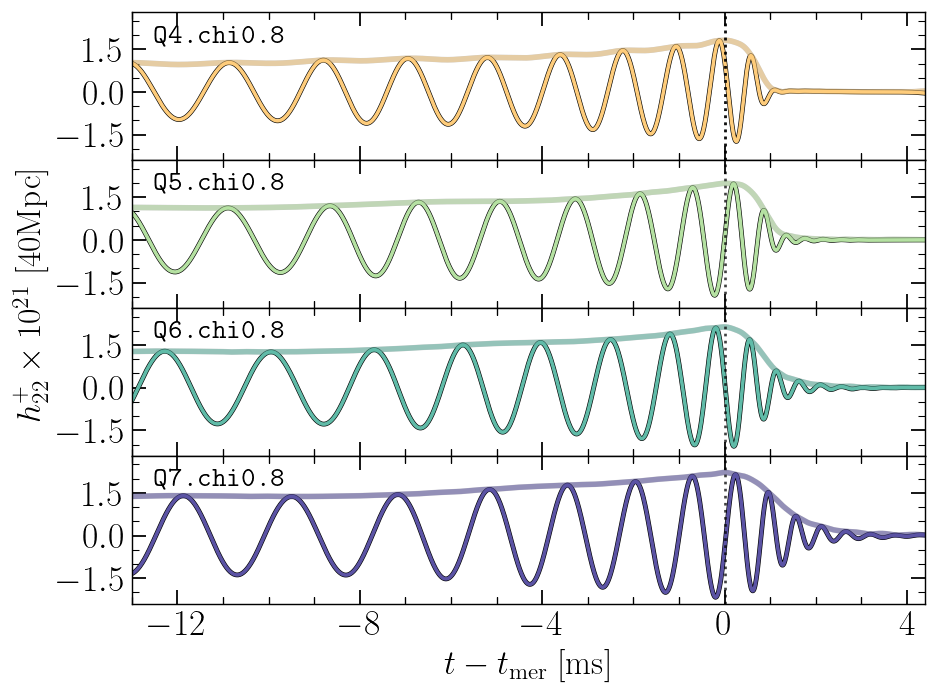

In [2]:
fig, (ax1,ax2,ax3, ax4) = plt.subplots(figsize=(8,6), dpi=128,nrows=4,sharex=True)

gomega=0.008

# orbital period
T=2.*np.pi/gomega
# distance in Msun of detector of GW extraction
dist=300
#dist=500
dist=600

tMsolTomsec=0.00493
#fig_aux, ax_aux = plt.subplots(figsize=(10,5),dpi=128)
# orbital velocity from initial data
iters_to_merger_largest=-20
iters_to_merger_smallest=100000
#    "BHNS_VQCD_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times4_joined" : r"$\chi_{\rm BH}=0.8$",

sim_to_ax={
    # "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : ax1,
    # "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : ax2,
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : ax1,
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : ax2,
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : ax3 ,
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : ax4 ,
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2":ax1,

    }

sim_to_color={
   # "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : "firebrick",
   # "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : "forestgreen",
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : "royalblue",
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : "darkorchid",
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : "darkorange",
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : "sienna",
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2": "royalblue",

}


ColorScheme=0

if(ColorScheme==0):
    colormap=cm.get_cmap("Spectral")
    # colormap_numbers=[0.00,0.14,0.26,0.36,
    #                   0.68,0.81,0.99,0.38]
    colormap_numbers=[0.36,0.68,0.81,0.99,0.36]
    counter=0
    print(len(list(sim_to_color.keys())))
    for key in sim_to_title.keys():
        sim_to_color[key] = colormap(colormap_numbers[counter])
        counter+=1
    
if(ColorScheme==1):
    colormap=cm.get_cmap("rainbow")
    colormap_numbers=[0.00,0.14,0.26,0.36,
                      0.68,0.81,0.99,0.38]
    counter=0
    print(len(list(sim_to_color.keys())))
    for key in sim_to_title.keys():
        sim_to_color[key] = colormap(colormap_numbers[counter])
        counter+=1

if(ColorScheme==2):
    cm1=cm.get_cmap("Reds")
    cm2=cm.get_cmap("Purples")
    sim_to_color={
    "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : cm1(0.15),
    "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : cm1(0.4),
    "BHNS_DD2_q4_chiBH_0.6_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : cm1(0.7),
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : cm1(0.9), 
  #  "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : cm2(0.4),
  #  "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : cm2(0.7),#"darkorange",
  #  "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : cm2(0.9),
    
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2": cm1(0.9),
    }
    


sim_to_spin={
    "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : "0",
    "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : "0.4",
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : "0.8",
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : "0.8",
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : "0.8",
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2" : "0.8",
     "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : "0.8"          
}


sim_to_title={
   # "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : r"$\chi_{\rm BH} = 0 $" ,
   # "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : r"$\chi_{\rm BH} = 0.4 $",
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : r"$\chi_{_{\rm BH}} = 0.8, q^{-1}=4$",
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : r"$\chi_{_{\rm BH}} = 0.8, q^{-1}=5$",
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : r"$\chi_{_{\rm BH}} = 0.8, q^{-1}=6$" ,
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" :r"$\chi_{_{\rm BH}} = 0.8, q^{-1}=7$"   ,
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2" : r"$\chi_{_{\rm BH}} = 0.8, q^{-1}=4$, ecc. red.",

}


if(True):
    sim_to_title =   {
        #"BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : r"\texttt{Q4.chi0.0}",
        #"BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : r"\texttt{Q4.chi0.4}",
        #"BHNS_DD2_q4_chiBH_0.6_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : r"\texttt{Q4.chi0.6}",
        "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : r"\texttt{Q4.chi0.8}",
        "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : r"\texttt{Q5.chi0.8}",
        "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : r"\texttt{Q6.chi0.8}",
        #"BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_Z4c" : r"$\chi_{_{\rm BH}}=0.8, q^{-1}=7$",
        "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : r"\texttt{Q7.chi0.8}",
        #"BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : r"\texttt{Q4.chi0.8}",
        "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2" : r"\texttt{Q4.chi0.8.er}",
                        }
    print("changed")
    
    

sim_to_strain={
   # "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : None,
   # "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : None,
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : None,
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : None,
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : None,
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol": None,
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2" : None,

          }

sim_to_plot_bool = {
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : True,
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : True,
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol": True,
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol": True,
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2" : False,

}

counter=0
for sim in sim_to_title.keys():
    sim_dir= SimDir(dir+sim)
    
    # loading strain data of dominant l=m=2 mode
    strain=sim_dir.gws[dist].get_strain_lm(2,2,T,0.05,window_function='tukey',trim_ends=False)
    sim_to_tmer_ms[sim]=strain.x_at_abs_maximum_y()*tMsolTomsec
    print(sim, "t_mer = ", sim_to_tmer_ms[sim], "ms")
    strain.align_at_maximum()
    # extracting ++ and xx polarization
    # rescaling to 40 Mpc
    
    # by default, the strain in kuibit is given as r*(h_+ - i h_x),
    # rescaling of the strain is : r_1 / r_2 
    
    hpp=strain.real().y  /  (40. * MpcToLMsol) * 1e21
    hxx=-strain.imag().y /  (40. * MpcToLMsol) * 1e21

    
    # hpp=strain.real().y  /  (40. * MpcToLMsol) 
    # hxx=-strain.imag().y /  (40. * MpcToLMsol) 

    
    # locating maximum of GW amplitude
    amp=list(np.sqrt(hpp[:]**2+hxx[:]**2))
    max_amp=max(amp)
    i_max=amp.index(max_amp)
    time=strain.real().t
    tmerge=time[i_max]
    
    # converting time in ms, subtracting merger time and adding distance from GW extraction 
    #tms=(time-tmerge+dist)*tMsolTomsec
    tms=(time-tmerge+dist)*tMsolTomsec

    tmerge=tmerge-dist
    sim_to_strain[sim]=strain
    
    # if(counter==1):
    #     strain_t_extend=list(strain.t)
    #     strain_t_nonextend=list(strain.t)
    #     strain_t_extend=strain_t_extend+[strain.t[-1]+(strain.t[-1] - strain.t[-2])*i for i in range(1,200) ]
    #     #print(strain_t_extend)
    #     hpp_extend=list(hpp)
    #     hpp_extend=hpp_extend+[hpp[-1] for i in range(1,200)]
    #     sim_to_ax[sim].plot(tMsolTomsec*(strain_t_extend-tmerge), hpp_extend, label=sim_to_title[sim],color=sim_to_color[sim])
        
    #     amp_extend=list(amp)
    #     amp_extend=amp_extend+[np.exp(-i/5)*amp[-1] for i in range(1,200)] 
    #     sim_to_ax[sim].plot(tMsolTomsec*(strain_t_extend-tmerge), amp_extend, alpha=0.5,color=sim_to_color[sim])

    #     #sim_to_ax[sim].plot(tMsolToPostmergerToriXYsnapshot_rasterised.pdfmsec*(strain.t-tmerge), hpp, label=sim_to_title[sim],color=sim_to_color[sim])
    #     #amp=np.array(amp)    
    #     #sim_to_ax[sim].plot(tMsolTomsec*(strain.t-tmerge), amp, alpha=0.5,color=sim_to_color[sim])
    # else:
    if(sim_to_plot_bool[sim]):
        sim_to_ax[sim].plot(tMsolTomsec*(strain.t), hpp, label=sim_to_title[sim],color=sim_to_color[sim], linewidth=2)
        sim_to_ax[sim].plot(tMsolTomsec*(strain.t), hpp, color='black', linewidth=2.7,zorder=0.2)
        
        amp=np.array(amp)    
        sim_to_ax[sim].plot(tMsolTomsec*(strain.t), amp, alpha=0.5,color=sim_to_color[sim],linewidth=3)
        sim_to_ax[sim].plot(tMsolTomsec*(strain.t), amp, alpha=0.2,color='black',linewidth=3.2,zorder=0.2)
        
    #sim_to_ax[sim].text(-12.5,1.02, r"$\chi_{\rm BH} = %s $" % sim_to_spin[sim],fontsize=14)
        sim_to_ax[sim].text(-12.5,1.75, sim_to_title[sim],fontsize=16)
    sim_to_ax[sim].set_xlim(-13,4.4)
    sim_to_ax[sim].set_ylim(-2.4,2.8)
    yline=np.linspace(sim_to_ax[sim].get_ylim()[0],sim_to_ax[sim].get_ylim()[-1],20)
    
    sim_to_ax[sim].plot(0*np.zeros_like(yline), yline, color='black', alpha=0.75,zorder=2,
                        linestyle='dotted')
    counter+=1
    print(max_amp)
    #ax3.set_xlim(-10,1)

large_ticks=np.arange(np.ceil(sim_to_ax[sim].get_xlim()[0])+1, np.ceil(sim_to_ax[sim].get_xlim()[-1]),4) 
minor_loc_ticks=[tt + i *1 for i in range(-16,16) for tt in large_ticks]
minor_y_ticks=[-2.5,-2,-1.5,-1,-0.5,0,0.5,1,1.5,2,2.5,3.0]

for sim in sim_to_title.keys():
    sim_to_ax[sim].set_xticks(large_ticks)
    sim_to_ax[sim].set_yticks([-1.5,0,1.5])

    #ax.xaxis.set_minor_locator(minor_loc_ticks)
    sim_to_ax[sim].xaxis.set_minor_locator(FixedLocator(minor_loc_ticks))
    #sim_to_ax[sim].yaxis.set_minor_locator(FixedLocator(minor_loc_ticks))
    sim_to_ax[sim].yaxis.set_minor_locator(FixedLocator(minor_y_ticks))

    sim_to_ax[sim].xaxis.label.set_size(12)
    sim_to_ax[sim].yaxis.label.set_size(12)
    #ax.tick_params(axis='both', which='major', labelsize=15,length=5,width=0.5)
    #ax.tick_params(axis='both', which='minor', length=2,width=0.5)
    sim_to_ax[sim].tick_params(bottom=True, top=False, left=True, right=False ) 
    sim_to_ax[sim].tick_params(which='minor', width=0.6, length=4,labelsize=12,direction='in', color="black", bottom=True, top=True, left=True, right=True)                  
    sim_to_ax[sim].tick_params(which='major', width=1.0, length=8,labelsize=20,direction='in', color="black", bottom=True, top=True, left=True, right=True)                  

    
ax4.set_xlabel(r"$t - t_{\rm mer} \; [\rm{ms}] $" ,fontsize=19)
#ax2.set_ylabel(r"$h^{+}_{22} \times 10^{21} \; {\rm{at}} \; 40{\rm{Mpc}}, \; r_{\rm det}=%d M_{\odot}$ " % dist,fontsize=14, y=0.1)
ax2.set_ylabel(r"$h^{+}_{22} \times 10^{21} \; [40{\rm{Mpc}} ]$ " ,fontsize=19, y=0.1)
plt.subplots_adjust(hspace=0)

#plt.savefig("/home/konrad/Desktop/TalksMaterial/Valencia_2024_02_21/figs/BHNS_Strains_spin_dependence.pdf",dpi=128,bbox_inches='tight')
#plt.savefig("/home/konrad/tidaldisruption2024_paper/doc/figs/BHNS_strain_q4_q5_q6_q7_ChiBH_0.8.pdf",dpi=128,bbox_inches='tight')
plt.savefig("/home/konrad/tidaldisruption2024_paper/paperII/figs/BHNS_strain_q4_q5_q6_q7_ChiBH_0.8.pdf",dpi=128,bbox_inches='tight')
#plt.savefig("/home/konrad/tidaldisruption2024_paper/doc/figs/BHNS_strain_q4_q5_q7_ChiBH_0.8.pdf",dpi=128,bbox_inches='tight')
#plt.savefig("/home/konrad/tidaldisruption2024_paper/doc/figs/BHNS_strain_q4_q5_q6_q7_ChiBH_0.8.pdf",dpi=128,bbox_inches='tight')
plt.show()



In [3]:
N_increase_f_resolution=1
savgol_window_size=11
savgol_window_order=5
msun_in_km=1.477  # in km
pc_in_km = 3.08567758 * 10**13 #in km
pc_in_msun=pc_in_km/msun_in_km
mpc40=40*pc_in_msun


# effective strain as done in PostCactus gw_utils
def h_eff(strain, polarization="both", truncate_inspiral=False, end=None):
    from scipy import signal
    from kuibit.frequencyseries import FrequencySeries
    ts = strain.regular_resampled()
    if truncate_inspiral:
    # sets t=0 to strain max    
        ts.align_at_maximum()
    # clips all data up to t=0
        ts.clip(init=0)

    if end != None:
        ts.clip(end=end)

    # We extract the plus and cross components of the strain
    # Note: for an unaltered Kuibit strain, this will in reality be
    # r * hp, r * hc respectively
    hp = ts.real()
    hc = -ts.imag()
  
    # Then, we take the Fourier transform.
    # By extracting hp and hc seperately we obtain
    # the real signal only in the positive frequency space
    hp_fft = hp.to_FrequencySeries()
    hc_fft = hc.to_FrequencySeries()

    # Finally, we can compute the effective strain amplitude 
    # power spectral density akin to [Eq (8-9) in 1604.00246].
    # For a full discussion, see https://github.com/Sbozzolo/kuibit/pull/27
    h_eff = hp_fft
    
    print("Doing polarization: ", polarization)

    if(polarization=="+"):
        h_eff.fft = h_eff.fft = h_eff.f * np.sqrt(
                 (hp_fft.amp**2. ) / 2.0
                )

    elif(polarization=="x"):
        h_eff.fft = h_eff.fft = h_eff.f * np.sqrt(
                 (hc_fft.amp**2. ) / 2.0
                )
    elif(polarization=="both"):
        h_eff.fft = h_eff.f * np.sqrt(
        (hp_fft.amp**2. + hc_fft.amp**2.) / 2.0
          )
    
    else:
        print("YOU MUST CHOOSE POLARIZATION!")

    return h_eff  

'''
    PSD computed in the same fashion as Jen's
    fmin/fmax = in [kHz]
'''

def return_psd(strain22, strain21, polarization, interpolation, filtering,
               savgol_window_size, savgol_window_order, smoothing_at_the_end,
               fmin=0.5, fmax=5.2, fmer=None, tmax=None):
    from kuibit.frequencyseries import FrequencySeries
    
    total_strain_22 = strain22.copy()
    total_strain_21 = strain21.copy()

  # convert to ms
    total_strain_22.t = total_strain_22.t * 1e3
    total_strain_21.t = total_strain_21.t * 1e3

    
  # Get full PSD
    heff_22 = h_eff(total_strain_22, polarization, end=tmax)
    heff_21 = h_eff(total_strain_21, polarization, end=tmax)
    
    # Get PSD from merger to simulation end time
    heff_22_sub = h_eff(total_strain_22, polarization, truncate_inspiral=True, end=tmax)
    
    t_after_merg=total_strain_22.t[-1] - total_strain_22.x_at_abs_maximum_y()
    t_before_merg=(total_strain_22.t[-1]-total_strain_22.t[0])-t_after_merg
    
    #print("Signal duration (not necessarily meaning the signal lifetime(e.g. collapse) is equal to this number) after the merger: ", t_after_merg)
          
    #part of the h_21 strain AFTER the merger (inspiral truncated)
    total_strain_21_sub=copy.deepcopy(total_strain_21)
    total_strain_21_sub.crop(t_before_merg,total_strain_21.t[-1])
    # this is PSD from h_21_truncated_inspiral!
    heff_21_sub=h_eff(total_strain_21_sub, polarization, end=tmax)

    #high and low frequency pass 
    for heff in [heff_21_sub,heff_22_sub, heff_21, heff_22]:
        heff=heff.high_passed(fmin)
        heff=heff.low_passed(fmax)
            

  # frequency interpolation range
    f_interp = np.linspace(np.max([heff_21_sub.f[1],
                                   heff_22_sub.f[1],
                                   heff_22.f[1],
                                   heff_21.f[1]]
                                   #fmin],
                                 ), 
                           # fmin
                            fmax, num=len(heff_22.f)*N_increase_f_resolution)
    #savgol filtering
    
    if(filtering=="savgol"):
        heff_21_sub.savgol_smooth(savgol_window_size,savgol_window_order)
        heff_22_sub.savgol_smooth(savgol_window_size,savgol_window_order)
        heff_21.savgol_smooth(savgol_window_size,savgol_window_order)
        heff_22.savgol_smooth(savgol_window_size,savgol_window_order)
        
    elif(filtering=="moving_avg"):
        from scipy.ndimage import uniform_filter1d
        moving_avg_size=5
        heff_21_sub.fft=uniform_filter1d(heff_21_sub.fft, size=moving_avg_size)
        heff_21.fft=uniform_filter1d(heff_21.fft, size=moving_avg_size)
        heff_22_sub.fft=uniform_filter1d(heff_22_sub.fft, size=moving_avg_size)
        heff_22.fft=uniform_filter1d(heff_22.fft, size=moving_avg_size)

    if(interpolation=='resample'):
        #print("Simple resampling")
        #print("Resampling, not piecewise constant")
        heff_21_sub.resample(f_interp, piecewise_constant=False)
        heff_22_sub.resample(f_interp, piecewise_constant=False)
        heff_21.resample(f_interp, piecewise_constant=False)
        heff_22.resample(f_interp, piecewise_constant=False)
    # resampling in f_interp
    if(interpolation=='resample_pconst'):
        #print("Resampling, piecewise constant")
        heff_21_sub.resample(f_interp, piecewise_constant=True)
        heff_22_sub.resample(f_interp, piecewise_constant=True)
        heff_21.resample(f_interp, piecewise_constant=True)
        heff_22.resample(f_interp, piecewise_constant=True)
    
    # or spline interpolation in f_interp
    elif(interpolation=='spline'):
        heff_21_sub=FrequencySeries(f_interp,heff_21_sub.evaluate_with_spline(f_interp))
        heff_22_sub=FrequencySeries(f_interp,heff_22_sub.evaluate_with_spline(f_interp))
        heff_21    =FrequencySeries(f_interp,heff_21.evaluate_with_spline(f_interp))
        heff_22    =FrequencySeries(f_interp,heff_22.evaluate_with_spline(f_interp) )

    else:
         print("Not doing resampling nor spline interpolation")
        
        
    if(smoothing_at_the_end):
        print("Smoothing at the end")
        heff_21_sub=heff_21_sub.savgol_smoothed(201,2)
        heff_22_sub=heff_22_sub.savgol_smoothed(201,2)
        heff_21=heff_21.savgol_smoothed(201,2)
        heff_22=heff_22.savgol_smoothed(201,2)

        
    #scalefac = lambda f: 2. / f * np.sqrt(2. * f / 1.e3) / (40. * unit.MpcToLMsol)
    scalefac = lambda f: 2. / f * np.sqrt(2. * f / 1.e3) / (mpc40)

    
    #initializing PSDs' x-axis (frequency)
    #psd_22_sub_f = psd_21_sub_f = psd_22_f = psd_21_f=f_interp
    
    #initializing PSDs' y-axis (htilde(f)*\sqrt(f) etc...)
    
    psd_22_sub_fft=scalefac(heff_22_sub.f)*heff_22_sub.fft
    psd_21_sub_fft=scalefac(heff_21_sub.f)*heff_21_sub.fft
    psd_22_fft=scalefac(heff_22.f)*heff_22.fft
    psd_21_fft=scalefac(heff_21.f)*heff_21.fft
    

    return (f_interp, psd_22_fft, psd_21_fft, psd_22_sub_fft, psd_21_sub_fft)
    #return (psd_22_f, psd_21_f, psd_22_sub_f,psd_21_Wsub_f,psd_22_fft, psd_21_fft, psd_22_sub_fft, psd_21_sub_fft)
           
    
def return_psd_only22(strain22, polarization, interpolation, filtering,
               savgol_window_size, savgol_window_order, smoothing_at_the_end,
               fmin=0.2, fmax=5.2, fmer=None, tmax=None):
    from kuibit.frequencyseries import FrequencySeries
    
    total_strain_22 = strain22.copy()

  # convert to ms
    total_strain_22.t = total_strain_22.t * 1e3

    
  # Get full PSD
    heff_22 = h_eff(total_strain_22, polarization, end=tmax)
    
    # Get PSD from merger to simulation end time
    heff_22_sub = h_eff(total_strain_22, polarization, truncate_inspiral=True, end=tmax)
    
    t_after_merg=total_strain_22.t[-1] - total_strain_22.x_at_abs_maximum_y()
    t_before_merg=(total_strain_22.t[-1]-total_strain_22.t[0])-t_after_merg
    
    #print("Signal duration (not necessarily meaning the signal lifetime(e.g. collapse) is equal to this number) after the merger: ", t_after_merg)
          

    #high and low frequency pass 
    for heff in [heff_22_sub, heff_22]:
        heff=heff.high_passed(fmin)
        heff=heff.low_passed(fmax)
            

  # frequency interpolation range
    f_interp = np.linspace(np.max([heff_22_sub.f[1],
                                   heff_22.f[1]]                        #fmin],
                                 ), 
                           # fmin
                            fmax, num=len(heff_22.f)*N_increase_f_resolution)
    #savgol filtering
    
    if(filtering=="savgol"):
        heff_22_sub.savgol_smooth(savgol_window_size,savgol_window_order)
        heff_22.savgol_smooth(savgol_window_size,savgol_window_order)
        
    elif(filtering=="moving_avg"):
        from scipy.ndimage import uniform_filter1d
        moving_avg_size=5
        heff_22_sub.fft=uniform_filter1d(heff_22_sub.fft, size=moving_avg_size)
        heff_22.fft=uniform_filter1d(heff_22.fft, size=moving_avg_size)

    if(interpolation=='resample'):
        print("Simple resampling")
        print("Resampling, not piecewise constant")
        heff_22_sub.resample(f_interp, piecewise_constant=False)
        heff_22.resample(f_interp, piecewise_constant=False)
    # resampling in f_interp
    if(interpolation=='resample_pconst'):
        print("Resampling, piecewise constant")
        heff_22_sub.resample(f_interp, piecewise_constant=True)
        heff_22.resample(f_interp, piecewise_constant=True)
    
    # or spline interpolation in f_interp
    elif(interpolation=='spline'):
        heff_22_sub=FrequencySeries(f_interp,heff_22_sub.evaluate_with_spline(f_interp))
        heff_22    =FrequencySeries(f_interp,heff_22.evaluate_with_spline(f_interp) )

    else:
         print("Not doing resampling nor spline interpolation")
        
        
    if(smoothing_at_the_end):
        print("Smoothing at the end")
        heff_22_sub=heff_22_sub.savgol_smoothed(201,2)
        heff_22=heff_22.savgol_smoothed(201,2)

        
    #scalefac = lambda f: 2. / f * np.sqrt(2. * f / 1.e3) / (40. * unit.MpcToLMsol)
    scalefac = lambda f: 2. / f * np.sqrt(2. * f / 1.e3) / (mpc40)

    
    #initializing PSDs' x-axis (frequency)
    #psd_22_sub_f = psd_21_sub_f = psd_22_f = psd_21_f=f_interp
    
    #initializing PSDs' y-axis (htilde(f)*\sqrt(f) etc...)
    
    psd_22_sub_fft=scalefac(heff_22_sub.f)*heff_22_sub.fft
    psd_22_fft=scalefac(heff_22.f)*heff_22.fft
    

    return (f_interp, psd_22_fft, psd_22_sub_fft)
    #return (psd_22_f, psd_21_f, psd_22_sub_f,psd_21_Wsub_f,psd_22_fft, psd_21_fft, psd_22_sub_fft, psd_21_sub_fft)
# Mtot_OmegaISCO_Taniguchi
# 0.10539558550602592 1.083234932254923 1.2746799449186632
def function_ISCO_tanig_MADM_0(comp,qhat):
    A=0.10539558550602592
    B=1.083234932254923
    C=1.2746799449186632
    return A*(1 - B*(1-C*comp**(1/3))/qhat**(0.25))

def function_ISCO_tanig_MADM_0_WithChiBH(comp,qhat,ChiBH):
    return function_ISCO_tanig_MADM_0(comp,qhat)*f_of_ChiBH_qhat_MS(ChiBH,qhat)
    öftermal
# Mtot_Omega_ISCO function's best-fit parameters for the ChiBH=0 for EOS_intermediate: 

#    a:  0.03777122 +/- 0.00637011 (16.86%) (init = 0.07)
#    b:  0.56840409 +/- 0.17371817 (30.56%) (init = 0.4)
#    p: -2.02959997 +/- 0.05662810 (2.79%) (init = -0.8)

# def function_ISCO(comp,qhat, MADM_0,a=0.03777122,b=0.56840409,p=-2.02959997):
#     return a*(1/MADM_0)*(1+ b/qhat**(1+p*comp**(1/3)))**(3/2)# + a0 + b0*comp
# def function_ISCO_MADM_0(comp,qhat,a=0.03777122,b=0.56840409,p=-2.02959997):
#     return a*(1+ b/qhat**(1+p*comp**(1/3)))**(3/2)# + a0 + b0*comp

# Mtot_Omega_MS function's best-fit parameters for the ChiBH=0 for EOS_intermediate: 
#     a:  0.30505910 +/- 0.00513508 (1.68%) (init = 0.32)
#     b:  4.49605512 +/- 0.44762083 (9.96%) (init = 0)
#     c: -0.00976210 +/- 0.00188670 (19.33%) (init = 0)

# TD: 0.26096967276939537 1.9115355588532597 -0.009881325806536506

def function_TD_MADM_0_modified(comp,qhat, a=0.26096967276939537,b=1.9115355588532597,c=-0.009881325806536506, boolGam2=False):
    if(boolGam2):
        a=0.33429
        b=-0.21766
        c=-0.002866
        
    return (a)*(comp**(3/2))*(1+b*comp)*(1+c*qhat)*(1+qhat)*(1+1/(qhat))**(1/2)
    
def function_TD_modified(comp,qhat, MADM_0,  a=0.26096967276939537,b=1.9115355588532597,c=-0.009881325806536506,boolGam2=False):
    return function_TD_MADM_0_modified(comp,qhat,a,b,c,boolGam2)*(1/MADM_0)
    
    
# ISCO: 0.10969079343179548 -0.26786361419324145 0.7868984189995946
def function_ISCO_modified(comp,qhat, MADM_0,a=0.10969079343179548,alpha= -0.2678636141932414,beta=0.7868984189995946):
    return (1/MADM_0)*(6**(-3./2.))*(1+a/(qhat**alpha))*(1+a*comp**beta)# + a0 + b0*comp

def function_ISCO_MADM_0_modified(comp,qhat,a=0.10969079343179548,alpha= -0.2678636141932414,beta=0.7868984189995946):
    return (6**(-3./2.))*(1+a/(qhat**alpha))*(1+a*comp**beta)


def function_ISCO_modified_3(comp,qhat, MADM_0,a=0.12576568,alpha= -0.27657493,beta= 1.15062643,boolGam2=False):
    if(boolGam2):
        a=0.57464
        alpha=0.44673
        beta=0.67579
    return (1/MADM_0)*(6**(-3./2.))*(1+a/(qhat**alpha))*(1+a*(1/qhat)*comp**beta)# + a0 + b0*comp
def function_ISCO_MADM_0_modified_3(comp,qhat,a=0.12576568, alpha=-0.27657493,beta=1.15062643, boolGam2=False):
    if(boolGam2):
        a=0.57464
        alpha=0.44673
        beta=0.67579
    return (6**(-3./2.))*(1+a/(qhat**alpha))*(1+a*(1/qhat)*comp**beta)


# ISCO spin dependence for a rescaled function; (a, b, c) =  0.45541219599182214 0.8190143648800697 1.0101612954462902
def f_of_ChiBH_ISCO(ChiBH, a=0.45541219599182214, b= 0.8190143648800697, c=1.010161295446290):
    return a*ChiBH*ChiBH + b*ChiBH + c

# MS spin dependence for a rescaled function; (a, b, c) =  -0.014945933829817166 0.05763875568419102 1.000303923279402
def f_of_ChiBH_MS(ChiBH, val, a=-0.014945933829817166, b=0.05763875568419102 , c=1.000303923279402):
    return a*ChiBH*ChiBH + b*ChiBH + c

# [[Variables]]
#     a: -0.01539146 +/- 0.00110270 (7.16%) (init = 0.1)
#     b:  0.00773953 +/- 0.00321133 (41.49%) (init = 0.05)
#     c:  1.00032183 +/- 4.5648e-04 (0.05%) (init = 0.02)
#     d:  0.01006114 +/- 6.3829e-04 (6.34%) (init = 0.002)
# MS (spin,qhat) dependence - the one to be used 
def f_of_ChiBH_qhat_MS(ChiBH, qhat, a=-0.01539146, b=0.00773953, c= 1.00032183 , d=0.01006114):
    return (a*ChiBH*ChiBH + b*ChiBH + c)*(1+ d*ChiBH*qhat)

# finally, MS and ISCO predictors with non-zero BH spin:

def function_ISCO_MADM_0_WithChiBH(comp,qhat,ChiBH, boolGam2=False):
    #return function_ISCO_MADM_0_modified(comp,qhat)*f_of_ChiBH_ISCO(ChiBH)
    return function_ISCO_MADM_0_modified_3(comp,qhat,boolGam2)*f_of_ChiBH_ISCO(ChiBH)

def function_TD_MADM_0_WithChiBH(comp,qhat,ChiBH, boolGam2=False):
    return function_TD_MADM_0_modified(comp,qhat,boolGam2)*f_of_ChiBH_qhat_MS(ChiBH,qhat)
    

In [4]:
CU_time=4.925553195445955e-06
for sim in sim_to_strain.keys():
    sim_to_strain[sim] = sim_to_strain[sim].time_unit_changed(CU_time, inverse=True).copy()

BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined
Find f_mer:
0.0 -0.02912302284552157 0.008121252108651292
f_mer:  1.2819267032695387  kHz
Find f_efold:
Find index_efold: 4241
BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4
Find f_mer:
0.0 -0.02156210166838422 0.010024485863371606
f_mer:  1.2020356580660332  kHz
Find f_efold:
Find index_efold: 1806
BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol
Find f_mer:
0.0 -0.020855974362285083 0.009923610533928876
f_mer:  1.242354871625421  kHz
Find f_efold:
Find index_efold: 1775
BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol
Find f_mer:
0.0 -0.020717270784301325 0.010163189441355368
f_mer:  1.1169047697586283  kHz
Find f_efold:
Find index_efold: 1816


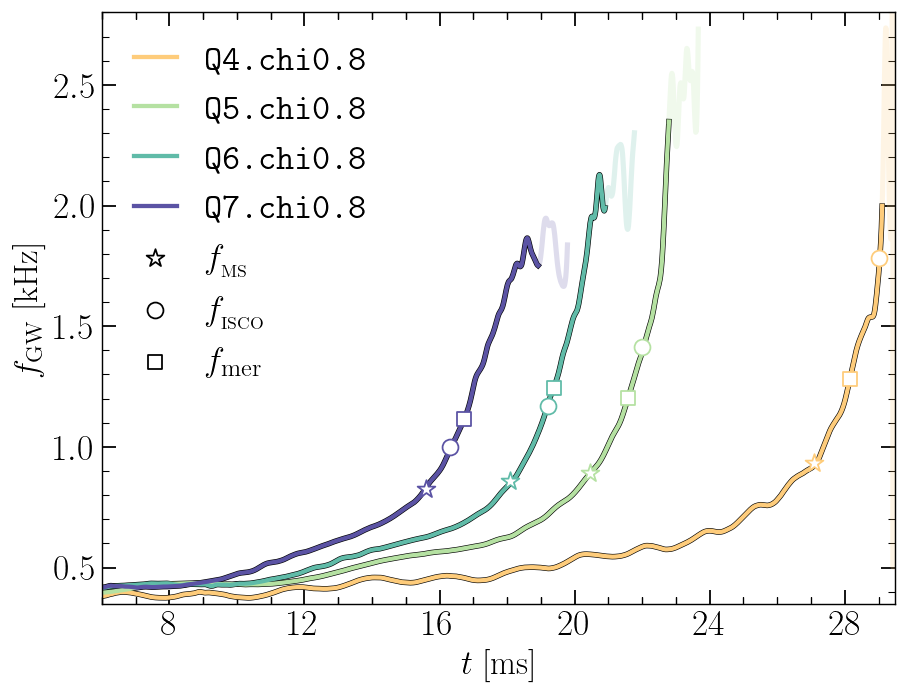

In [7]:
#fGW=sim_to_strain["BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined"].phase_frequency().abs()
fig, ax = plt.subplots(figsize=(8,6),dpi=128)


sim_to_cut_fgw={
   # "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : 2400,
   # "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : 3000,
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : 4050,
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : 1750,
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : 1850,
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : 1820,
          }

sim_to_shift_time={
   # "BHNS_VQCD_q4_chiBH_0_Mtot_7_Z4c_eta_MB_R0_times4" : 2400,
   # "BHNS_VQCD_q4_chiBH_0.4_Mtot_7_Z4c_eta_MB_R0_times4" : 3000,
    "BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined" : -1,
    "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" : 0,
    "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" : -1.5,
    "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" : -4,
          }

for sim in sim_to_strain.keys():
    if(False):
        print(sim)
        fGW=sim_to_strain[sim].phase_frequency().abs()
        #ax.semilogy(f_interp, psd_22, color=sim_to_color[sim],
        #           label=sim_to_title[sim])
        #plt.plot(fGW.t[:sim_to_cut_fgw[sim]]*1000,fGW.y[:sim_to_cut_fgw[sim]]/1000, color=sim_to_color[sim], label=sim_to_title[sim])
        ax.plot(fGW.t[:sim_to_cut_fgw[sim]+1]*1000 + sim_to_tmer_ms[sim] + sim_to_shift_time[sim],fGW.y[:sim_to_cut_fgw[sim]+1]/1000, color=sim_to_color[sim], label=sim_to_title[sim],
               linewidth=2.0+0.4)
        
        ax.plot(fGW.t[:sim_to_cut_fgw[sim]+1]*1000 + sim_to_tmer_ms[sim] + sim_to_shift_time[sim],fGW.y[:sim_to_cut_fgw[sim]+1]/1000, 
                color='black', alpha=1.0,linewidth=2.7+0.4,
                zorder=0.5)
        
        ax.plot(fGW.t[sim_to_cut_fgw[sim]:sim_to_cut_fgw[sim]+50]*1000 + sim_to_tmer_ms[sim] + sim_to_shift_time[sim],
                fGW.y[sim_to_cut_fgw[sim]:sim_to_cut_fgw[sim]+50]/1000,
                linewidth=2.0+0.4,
                color=sim_to_color[sim],alpha=0.2)
    
        # at this point, the fGW and sim_to_strain timeseries are aligned at the maximum of amplitude
        print("Find f_mer:")
        index_t_mer=np.where(fGW.t>=0)[0][0]
        print(fGW.t[index_t_mer], fGW.t[0], fGW.t[-1])
        f_mer=fGW.y[index_t_mer]/1000
        print("f_mer: ", f_mer, " kHz" )
        ax.scatter(fGW.t[index_t_mer]*1000 + sim_to_tmer_ms[sim] + sim_to_shift_time[sim],
                   f_mer,
                   marker='s', color=sim_to_color[sim],facecolor='white',zorder=2, s=30)
    if(True):
        if(sim_to_plot_bool[sim]):
            print(sim)
            fGW=sim_to_strain[sim].phase_frequency().abs()
            
            # find the f_mer frequency:
            print("Find f_mer:")
            index_t_mer=np.where(fGW.t>=0)[0][0]
            print(fGW.t[index_t_mer], fGW.t[0], fGW.t[-1])
            f_mer=fGW.y[index_t_mer]/1000
            print("f_mer: ", f_mer, " kHz" )
          
            # find when the amplitude decreases by an e-fold
            index_efold=np.where((sim_to_strain[sim].abs().y / sim_to_strain[sim].abs().y[index_t_mer] < (1/np.e)**2 ) &
                                 (sim_to_strain[sim].abs().t > 0)
                                )[0][0]
            
            # index_efold=np.where((sim_to_strain[sim].abs().y / sim_to_strain[sim].abs().y[index_t_mer] < 0.05 ) &
            #                      (sim_to_strain[sim].abs().t > 0)
            #                     )[0][0]
            print("Find f_efold:")
            print("Find index_efold:", index_efold)
            #t_efold=
            
            index_cut=sim_to_cut_fgw[sim] #arbitrary
            
            index_cut=index_efold # by an e-fold
             
            #index_cut = -1 # turn it off - the whole signal
        
            
            #ax.semilogy(f_interp, psd_22, color=sim_to_color[sim],
            #           label=sim_to_title[sim])
            #plt.plot(fGW.t[:sim_to_cut_fgw[sim]]*1000,fGW.y[:sim_to_cut_fgw[sim]]/1000, color=sim_to_color[sim], label=sim_to_title[sim])
            ax.plot(fGW.t[:index_cut+1]*1000             + sim_to_tmer_ms[sim]+sim_to_shift_time[sim],fGW.y[:index_cut+1]/1000, color=sim_to_color[sim], label=sim_to_title[sim], linewidth=2+0.4)
            ax.plot(fGW.t[:index_cut+1]*1000             + sim_to_tmer_ms[sim]+sim_to_shift_time[sim],fGW.y[:index_cut+1]/1000, color='black', linewidth=2.7+0.4,zorder=0.2)
            ax.plot(fGW.t[index_cut:index_cut+70]*1000 + sim_to_tmer_ms[sim]+sim_to_shift_time[sim],fGW.y[index_cut:index_cut+70]/1000, color=sim_to_color[sim],alpha=0.2, linewidth=2.5+0.4)
            
            ax.scatter(fGW.t[index_t_mer]*1000 + sim_to_tmer_ms[sim] +sim_to_shift_time[sim], #+ sim_to_shift_time[sim],
                       f_mer,
                       marker='s', color=sim_to_color[sim],facecolor='white',zorder=2, s=70)
# q^{-1} BH spin |  MS frequency            |  ISCO frequncy
# eos = Gam2
# 4 0 1.025037331109491 0.8642215887278055
# 4 0.4 1.0421974689791849 1.2068364642437848
# 4 0.6 1.0488470616176697 1.4248980653204772
# 4 0.8 1.0541690475338816 1.6741291086096386
# 5 0.8 1.0379067948973852 1.3530608260089965
# 6 0.8 1.0283096984994402 1.1338709345891032
# 7 0.8 1.022586413844899 0.97486216181402
# eos = inter
# 4 0 1.025037331109491 0.7537663068996339
# 4 0.4 1.0421974689791849 1.052591923818926
# 4 0.6 1.0488470616176697 1.242783293560291
# 4 0.8 1.0541690475338816 1.4601603708228015
# 5 0.8 1.0379067948973852 1.2279525742549986
# 6 0.8 1.0283096984994402 1.0609349363069425
# 7 0.8 1.022586413844899 0.9349046401002314
# eos = stiff

# 4 0.8 1.0541690475338816 1.3589899403657226
# 5 0.8 1.0379067948973852 1.1452567991746323
# 6 0.8 1.0283096984994402 0.9917601551449022
# 7 0.8 1.022586413844899 0.8760509298448255

# simname="BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined"
# ax.scatter(27.5, 1.0541690475338816, marker='*', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=65)
# ax.scatter(28.2, 1.3589899403657226, marker='o', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=40)

# simname=   "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" 
# ax.scatter(21.1  , 1.0379067948973852 , marker='*', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=65)
# ax.scatter(21.4 , 1.1452567991746323, marker='o', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=40)

# simname=   "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" 
# ax.scatter(18.8 , 1.0283096984994402, marker='*', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=65)
# ax.scatter(18.7 ,  0.9917601551449022, marker='o', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=40)

# simname=   "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" 
# ax.scatter(20.1-3.7, 1.022586413844899, marker='*', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=65)
# ax.scatter(19.4-3.5, 0.8760509298448255, marker='o', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=40)



# eos = DD2
# 4 0 0.9191921184352856 0.8891578630839688
# 4 0.4 0.9301466202134979 1.2009949151745507
# 4 0.6 0.9333112610844758 1.4583351617398856

# 4 0.8 0.9349562674216111 1.7832898886519166
# 5 0.8 0.8927934200770228 1.4152388785201073
# 6 0.8 0.8575063673850564 1.1714107205981574
# 7 0.8 0.8262912854523344 0.9982498224991948 

# Q CHIBH freq_MS, freq_ISCO


simname="BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined"
ax.scatter(27.1, 0.9349562674216111 , marker='*', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=110)
ax.scatter(29, 1.7832898886519166, marker='o', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=80)

simname=   "BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4" 
ax.scatter(20.45  , 0.8927934200770228 , marker='*', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=110)
ax.scatter(22 , 1.4152388785201073, marker='o', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=80)

simname=   "BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol" 
ax.scatter(18.1 , 0.8575063673850564, marker='*', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=110)
ax.scatter(19.2 ,  1.1714107205981574, marker='o', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=80)

simname=   "BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol" 
ax.scatter(20.1-4.5, 0.8262912854523344, marker='*', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=110)
ax.scatter(19.4-3.1, 0.9982498224991948, marker='o', edgecolor=sim_to_color[simname], facecolor='white',zorder=2, s=80)



#plt.plot([16.7,22.25,28.95], [1.17, 1.1914, 1.205], color='black', alpha=0.2, zorder=0.5,linestyle='dotted')
#plt.plot([15.6,21.95,29.5], [0.754, 1.053, 1.461], color='black', alpha=0.2, zorder=0.5, linestyle='dotted')

ax.scatter([],[], marker='*', edgecolor='black', facecolor='white',zorder=2, s=110, label=r'$f_{_{\rm MS}}$')
ax.scatter([],[], marker='o', edgecolor='black', facecolor='white',zorder=2, s=80, label=r'$f_{_{\rm ISCO}}$')
ax.scatter([],[], marker='s', edgecolor='black', facecolor='white',zorder=2, s=70, label=r'$f_{\rm mer}$')


large_ticks=np.arange(np.ceil(ax.get_xlim()[0])+1, np.ceil(ax.get_xlim()[-1]),4) 
minor_loc_ticks=[tt + i *1 for i in range(-16,16) for tt in large_ticks]
y_ticks=[0,0.5,1,1.5,2,2.5]
minor_y_ticks=[0.1*i for i in range(30)]

ax.set_xticks(large_ticks)
ax.set_yticks(y_ticks)
#     sim_to_ax[sim].set_yticks([-1.5,0,1.5])

ax.xaxis.set_minor_locator(FixedLocator(minor_loc_ticks))
ax.yaxis.set_minor_locator(FixedLocator(minor_y_ticks))

#     #sim_to_ax[sim].yaxis.set_minor_locator(FixedLocator(minor_loc_ticks))

#     sim_to_ax[sim].xaxis.label.set_size(12)
#     sim_to_ax[sim].yaxis.label.set_size(12)
#     #ax.tick_params(axis='both', which='major', labelsize=15,length=5,width=0.5)
#     #ax.tick_params(axis='both', which='minor', length=2,width=0.5)
ax.tick_params(bottom=True, top=False, left=True, right=False ) 
ax.tick_params(which='minor', width=0.6, length=4,labelsize=12,direction='in', color="black", bottom=True, top=True, left=True, right=True)                  
ax.tick_params(which='major', width=1.0, length=8,labelsize=20,direction='in', color="black", bottom=True, top=True, left=True, right=True)                  

ax.set_ylabel(r"$f_{\rm GW}\; {\rm[kHz]}$",size=19)
ax.set_xlabel(r"$t\; [\rm{ms}]$",size=19)
 
ax.set_ylim(0.35,2.8)
ax.set_xlim(6,29.5)

#ax.set_xlabel(r"$t - t_{\rm mer} \; [ms] $" ,fontsize=15)
#ax.set_ylabel(r"$h^{+}_{22} \times 10^{21} \; {\rm{at}} \; 40Mpc, \; r_{\rm det}=%d M_{\odot}$ " % dist,fontsize=14, y=0.9)
plt.legend(edgecolor="none",facecolor='none',fontsize=20,handlelength=1.2)
#plt.savefig("/home/konrad/Desktop/TalksMaterial/Valencia_2024_02_21/figs/BHNS_f_GW_BH_spin_dep_with_marked_ISCO_MS.pdf",dpi=128,bbox_inches='tight')
#plt.savefig("/home/konrad/tidaldisruption2024_paper/doc/figs/BHNS_f_GW_BH_spin_dep_with_marked_ISCO_MS.pdf",dpi=128,bbox_inches='tight')
#plt.savefig("/home/konrad/tidaldisruption2024_paper/doc/figs/BHNS_fGW_q4_q5_q6_q7_ChiBH_0.8_with_marked_ISCO_MS.pdf",dpi=128,bbox_inches='tight')
plt.savefig("/home/konrad/tidaldisruption2024_paper/paperII/figs/BHNS_fGW_q4_q5_q6_q7_ChiBH_0.8_with_marked_ISCO_MS.pdf",dpi=128,bbox_inches='tight')
#plt.savefig("/home/konrad/tidaldisruption2024_paper/doc/figs/BHNS_fGW_q4_q5_q6_q7_ChiBH_0.8_with_marked_ISCO_MS.pdf",dpi=128,bbox_inches='tight')

plt.show()

BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_joined
Doing polarization:  both
Doing polarization:  both
Simple resampling
Resampling, not piecewise constant
Not doing resampling nor spline interpolation
BHNS_DD2_q5_chiBH_0.8_Mtot_8.4_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4
Doing polarization:  both
Doing polarization:  both
Simple resampling
Resampling, not piecewise constant
Not doing resampling nor spline interpolation
BHNS_DD2_q6_chiBH_0.8_Mtot_9.8_BSSN_fullevol
Doing polarization:  both
Doing polarization:  both
Simple resampling
Resampling, not piecewise constant
Not doing resampling nor spline interpolation
BHNS_DD2_q7_chiBH_0.8_Mtot_11.2_BSSN_fullevol
Doing polarization:  both
Doing polarization:  both
Simple resampling
Resampling, not piecewise constant
Not doing resampling nor spline interpolation
BHNS_DD2_q4_chiBH_0.8_Mtot_7_Z4c_eta_MB_R0_times5.6_alphaN_1_kappa0.02_CFL_0.4_ECC_RED_MANUAL_2
Doing polarization:  both
Doing polarization:  both
Simple resampling
Resampling, not pi

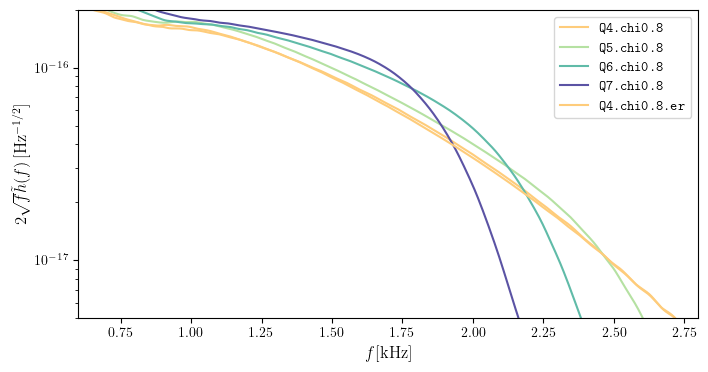

In [6]:
polarization="both"
interpolation="resample"
#filtering="none"
filtering="savgol"
smoothing_at_the_end=False

savgol_window_order=3
savgol_window_size=19


fig, ax=plt.subplots(figsize=(8,4), facecolor='white',dpi=100)

for sim in sim_to_strain.keys():
    print(sim)
    f_interp, psd_22, psd_22_sub=return_psd_only22(sim_to_strain[sim],
                                                                 polarization,
                                                                 interpolation,
                                                                 filtering,
                                                                 savgol_window_size,
                                                                 savgol_window_order,
                                                                 smoothing_at_the_end) 
    
    
    # fig_aux, ax_aux=   plt.subplots(figsize=(6,4), facecolor='white', dpi=128)
    # ax_aux.plot(sim_to_strain[sim].t*1000, sim_to_strain[sim].y, color='black', label=r"$h_{+}^{22}$")
    # ax_aux.set_xlabel(r"$t$ [ms]", fontsize=10)
    # ax_aux.set_ylabel(r"$R \;\; h_{+} [M]$, $R=200M_{\odot}$", fontsize=10)
    # plt.legend()
      
    #plt.clf()
    #plt.close("all")
    # fig_aux, ax_aux=   plt.subplots(figsize=(6,4), facecolor='white', dpi=100)
    # ax_aux.set_xlabel(r"$t$ [ms]", fontsize=10)
    # ax_aux.set_ylabel(r"$ \psi_{4,+} $, $R=300M_{\odot}$", fontsize=10)
    # plt.legend()
 
    #print("Savgol filter has a window of size:", (f_interp[savgol_window_size]-f_interp[0]), "kHz")
    
    
    ax.semilogy(f_interp, psd_22, color=sim_to_color[sim],
               label=sim_to_title[sim])
 
    
    psd_22_sub_full=FrequencySeries(f_interp,psd_22_sub)
  
#ax.set_ylabel(r"$2 \sqrt{f} \tilde{h}(f) \, {\rm [Hz^{-1/2}], \; 40 MPc}$",size=12)
ax.set_ylabel(r"$2 \sqrt{f} \tilde{h}(f) \, {\rm [Hz^{-1/2}]}$",size=12)
ax.set_xlabel(r"$f {\rm[kHz]}$",size=12)

ax.set_xlim(0.6,2.8)
ax.set_ylim(5e-18,2e-16)

plt.legend(loc=1)
qhat=4
MNS_ADM=1.4
val_comp=0.167650616
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0,0.4,0.8]:
    
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)

qhat=5
MNS_ADM=1.4
val_comp=0.167650616
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0.8]:
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)

    
qhat=7
MNS_ADM=1.4
val_comp=0.167650616
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0.8]:
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)

qhat=6
MNS_ADM=1.4
val_comp=0.167650616
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0.8]:
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)
    
qhat=5.3
MNS_ADM=1.4
val_comp=0.167650616
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0.8]:
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)
    
    
# freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
# freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
# print(chibh, freq_MS, freq_ISCO)

#plt.savefig("./core_f0_time_vs_freq_identification/psd"+NAME+".pdf", facecolor='white', dpi=100)

In [ ]:
qhat=(1./0.327)
MNS_ADM=1.3
MADM_0_value=(qhat+1)*MNS_ADM
chibh=0
freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for val_comp in [0.1454,0.16,0.1306]:
    
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(val_comp, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    #print(val_comp,  freq_MS, freq_ISCO)
    print(val_comp,  function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh))




In [ ]:
qhat=3
MNS_ADM=1.4
val_comp=0.17
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0.8]:
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)
    

# Using the ISCO and MS fit for the GAM2 EOS, and comparing with the dynamical simulations:

In [7]:
qhat=4
MNS_ADM=1.4
val_comp=0.167650616
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
boolGam2=False
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0,0.4,0.8]:
    
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh,boolGam2) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh,boolGam2) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)

qhat=5
MNS_ADM=1.4
val_comp=0.167650616
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0.8]:
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh,boolGam2) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh,boolGam2) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)

    
qhat=7
MNS_ADM=1.4
val_comp=0.167650616
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0.8]:
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh,boolGam2) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh,boolGam2) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)

qhat=6
MNS_ADM=1.4
val_comp=0.167650616
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0.8]:
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh,boolGam2) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh,boolGam2) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)
    
qhat=5.3
MNS_ADM=1.4
val_comp=0.167650616
MADM_0_value=(qhat+1)*MNS_ADM

freq_conv_1oM_to_kHz=202.8397
#for chibh in [0.5,0.7,0.9]:
print("\n \n \n \n ")
for chibh in [0.8]:
    freq_MS=2* function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh,boolGam2) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi) #correction factor to be similar to FF2018_hatMrem model # *0.75
    #freq_MS= function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh) / MADM_0_value   * freq_conv_1oM_to_kHz #correction factor to be similar to FF2018_hatMrem model # *0.75
    freq_ISCO= 2* function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh,boolGam2) / MADM_0_value   * freq_conv_1oM_to_kHz / (2* np.pi)
    #print(chibh, function_TD_MADM_0_WithChiBH(val_comp,qhat,chibh), function_ISCO_MADM_0_WithChiBH(val_comp,qhat,chibh), freq_MS, freq_ISCO)
    print(qhat, chibh, freq_MS, freq_ISCO)
    


 
 
 
 
4 0 0.0 0.6339702751567095
4 0.4 0.0 0.8853035555754407
4 0.8 0.0 1.2280971749334424

 
 
 
 
5 0.8 0.0 1.0234143124445356

 
 
 
 
7 0.8 0.0 0.7675607343334016

 
 
 
 
6 0.8 0.0 0.8772122678096019

 
 
 
 
5.3 0.8 0.0 0.9746802975662243
